# Matching Control Subjects for Premature Contraction Analysis

This notebook implements a matching procedure to find healthy control subjects from the LIFE study that are matched to subjects with premature contractions (PCs) based on demographic and physiological parameters.

## Overview

**Goal**: For each subject with premature contractions (either premature atrial contractions - PAC or premature ventricular contractions - PVC), find a matched healthy control subject based on:
- Age
- BMI (Body Mass Index)
- Blood pressure (when available)
- Sex (exact matching)

**Method**: k-Nearest Neighbors (k-NN) algorithm with standardized features

**Data sources**:
1. ECG parameters extracted from recordings
2. Demographic and physiological data from the LIFE study

## Import Required Libraries

In [ ]:
# this script could go in its own folder, e.g., analysis or so (feels lonely here)   
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

## Load ECG Analysis Data

Load the ECG parameters that were automatically extracted from the recordings using the CER-S software.

In [ ]:
# Load ECG parameters extracted from all subjects
# This file contains automated ECG analysis results including:
# - Heart rate variability parameters (RR intervals)
# - Detection of arrhythmias and premature contractions
# - Other cardiac rhythm parameters
ecg_data = pd.read_csv('data/matching/ecg_parameters.csv', delimiter=';')

In [14]:
# Extract subject IDs from the filename/path column
ecg_data['subject_id'] = ecg_data['NAME'].str.extract(r'(LI\d{7,8}X?)')

# Move subject_id to first column for better readability
subject_id_column = ecg_data.pop('subject_id')
ecg_data.insert(0, 'subject_id', subject_id_column)

# Remove rows without valid subject ID
ecg_data.dropna(axis=0, subset='subject_id', inplace=True)

## Load LIFE Study Data

Load demographic and physiological parameters from the LIFE (Leipzig Research Center for Civilization Diseases) study database.

In [ ]:
# Load LIFE study data containing:
# - Demographic information (age, sex, birth date)
# - Physiological measurements (BMI, blood pressure)
# - ECG/EEG recording dates and quality indicators
life_data = pd.read_csv('data/matching/life_study_parameters.csv', delimiter=';')

C:\Users\piare\AppData\Local\Temp\ipykernel_27980\606774651.py:5: DtypeWarning: Columns (8,32,34,36,38,283,319,320,321,322,323,324,337,338,339,340,341,342,343,344,345,346,347,348,354,361,362,393,394,401,410,433,434,435,436,437,438,439,440,441,442,443,444,446,447,448,462,518,520,531,573,577,581,585,589,593,597,601,605,608,718,722,726,730,734,744,784,785,792,825,832,834,838,840,842,849,857,872,887) have mixed types. Specify dtype option on import or set low_memory=False.
  life_data = pd.read_csv('life_study_parameters.csv', delimiter=';')


In [16]:
# Rename columns for clarity
life_data.rename(columns={'Column1': 'subject_id'}, inplace=True)
life_data.rename(columns=lambda x: x.replace('Table3.', ''), inplace=True)

# Remove unnecessary columns
life_data.drop(columns=['Column2'], inplace=True)

# Remove rows without valid subject ID or birth date
life_data.dropna(axis=0, subset=['subject_id', 'TEILNEHMER_GEB_JJJJMM_EEG'], inplace=True)

## Calculate Age at Time of EEG Recording

Compute the precise age of each subject at the time of their EEG recording by comparing birth date with recording date.

In [17]:
def convert_to_datetime(year_month_str):
    """Convert YYYYMM string format to datetime."""
    year = int(year_month_str[:4])
    month = int(year_month_str[4:6])
    return pd.Timestamp(year=year, month=month, day=1)

def calculate_age(birth_date, measurement_date):
    """Calculate age in years from birth date to measurement date."""
    age_days = (measurement_date - birth_date).days
    age_years = age_days / 365.25
    return age_years

# Parse birth date from YYYYMM format
life_data['birth_date'] = life_data['TEILNEHMER_GEB_JJJJMM_EEG'].astype(str).apply(convert_to_datetime)

# Parse measurement date
life_data['measurement_date'] = pd.to_datetime(life_data['EEG_DATUM'], dayfirst=True)

# Calculate age at measurement
life_data['age'] = life_data.apply(
    lambda row: calculate_age(row['birth_date'], row['measurement_date']), 
    axis=1
)

## Standardize Matching Features

Standardize the continuous variables (Age, BMI, Blood Pressure) to ensure equal weighting in the k-NN distance calculation. Each feature is normalized to have mean=0 and standard deviation=1.

In [18]:
# Features to be used for matching
matching_features = ['BMI_BMI', 'age', 'ADULT_BP_SBP', 'ADULT_BP_DBP']

# Calculate mean and standard deviation for standardization
feature_means = life_data[matching_features].mean()
feature_stds = life_data[matching_features].std()

# Create standardized versions of the features
life_data[[f"{col}_scaled" for col in matching_features]] = (
    (life_data[matching_features] - feature_means) / feature_stds
)

## Merge ECG Parameters with LIFE Data

Combine the ECG analysis results with the demographic and physiological data from the LIFE study.

In [19]:
# Merge ECG parameters with LIFE study data on subject_id
life_data_with_ecg = pd.merge(life_data, ecg_data, on='subject_id', how='left')

## Load Premature Contraction Subject List

Load the list of subjects that were identified as having premature contractions and classified into:
- **PAC**: Premature Atrial Contractions
- **PVC**: Premature Ventricular Contractions

In [ ]:
# Load list of subjects with premature contractions
pc_subject_list = pd.read_csv('data/matching/premature_contraction_subjects.csv', delimiter=',')

# Extract subject IDs
pc_subject_list['subject_id'] = pc_subject_list['ECG_subjnum_file'].str.extract(r'(LI\d{7,8}X?)')

# Move subject_id to first column
subject_id_column = pc_subject_list.pop('subject_id')
pc_subject_list.insert(0, 'subject_id', subject_id_column)

## Create Premature Contraction Subject Dataset

Merge the PC subject list with the complete dataset to get all relevant information for matching.

In [21]:
# Merge PC subject list with complete LIFE+ECG data
pc_subjects = pd.merge(pc_subject_list, life_data_with_ecg, on='subject_id', how='left')

In [22]:
# Display distribution of PC types
print("Distribution of premature contraction types:")
print(pc_subjects['group'].value_counts())

Distribution of premature contraction types:
group
V     52
SV    51
Name: count, dtype: int64


## Define Healthy Control Subject Pool

Create a pool of potential control subjects by applying strict inclusion criteria to ensure healthy cardiovascular status.

### Inclusion Criteria:

1. **Both EEG and ECG recordings available** and analyzed by CER-S software
2. **No pathological ECG findings** detected by automated analysis
3. **Complete EEG recording** (not aborted)
4. **Normal sinus rhythm** as documented in LIFE study
5. **No pacemaker** during recording

In [23]:
# Start with all subjects that have ECG analysis
healthy_controls = life_data_with_ecg.copy()

# Criterion 1: Must have ECG recording analyzed by CER-S
healthy_controls.dropna(axis=0, subset=['NAME'], inplace=True)
print(f"Subjects with ECG analysis: {len(healthy_controls)}")

Subjects with ECG analysis: 3237


In [24]:
# Criterion 2: No pathological ECG parameters detected
# List of all ECG parameters checked by CER-S
ecg_pathology_columns = [
    'Brady', 'Pauses', 'Prolonged RR', 
    'Isolated S', 'SV Couplet', 'SV Run', 'SV Bg', 'SV Tg', 'SV Tachy', 
    'ATachy', 'AFib', 'AFlutter', 
    'Isolated V', 'V Couplet', 'V Run', 'V Bg', 'V Tg', 'V Tachy', 
    'VFib', 'VFlutter', 'Torsade de P.', 
    'AVB', 'V Beats', 'S Beats'
]

# Keep only subjects where all parameters are negative ('-')
healthy_controls = healthy_controls[
    (healthy_controls[ecg_pathology_columns] == '-').all(axis=1)
]
print(f"Subjects without ECG pathologies: {len(healthy_controls)}")

Subjects without ECG pathologies: 1309


In [25]:
# Criterion 3: Complete EEG recording (not aborted)
healthy_controls.dropna(axis=0, subset='EEG_RUHE_I01', inplace=True)
print(f"Subjects with complete EEG: {len(healthy_controls)}")

Subjects with complete EEG: 1309


In [26]:
# Criterion 4: Normal sinus rhythm as documented in LIFE study
# EKGAUS_F0010 == 1 indicates sinus rhythm
indices_no_sinus = healthy_controls[healthy_controls['EKGAUS_F0010'] != 1].index
healthy_controls.drop(indices_no_sinus, inplace=True)
print(f"Subjects with sinus rhythm: {len(healthy_controls)}")

Subjects with sinus rhythm: 924


In [27]:
# Criterion 5: No pacemaker during recording
# EKGAUS_F0015 and EKGAUS_F0016 indicate pacemaker presence
indices_pacemaker = healthy_controls[
    (healthy_controls['EKGAUS_F0015'] == 1) | 
    (healthy_controls['EKGAUS_F0016'] == 1)
].index
healthy_controls.drop(indices_pacemaker, inplace=True)
print(f"Final healthy control pool: {len(healthy_controls)} subjects")

Final healthy control pool: 924 subjects


## Perform k-Nearest Neighbor Matching

For each PC subject, find the closest matching healthy control subject using k-NN algorithm.

### Matching Strategy:

1. **Primary matching** (preferred): Age + BMI + Blood Pressure
2. **Fallback matching** (if BP not available): Age + BMI only
3. **Sex matching**: Always exact (within-sex matching only)
4. **Without replacement**: Each control subject used only once

### Matching without Blood Pressure

First, perform matching using only Age and BMI (for subjects without blood pressure data).

In [28]:
# Remove subjects without BMI data
healthy_controls_bmi = healthy_controls.copy()
indices_missing_bmi = healthy_controls_bmi['BMI_BMI'].isna()
healthy_controls_bmi.drop(healthy_controls_bmi[indices_missing_bmi].index, inplace=True)

# Define features for matching without blood pressure
matching_features_no_bp = ['age_scaled', 'BMI_BMI_scaled']

In [29]:
# Perform k-NN matching stratified by sex
matches_no_bp = []
sex_categories = healthy_controls_bmi['TEILNEHMER_GESCHLECHT_EEG'].unique()

for sex in sex_categories:
    # Create sex-specific subsets
    controls_sex = healthy_controls_bmi[
        healthy_controls_bmi['TEILNEHMER_GESCHLECHT_EEG'] == sex
    ]
    pc_subjects_sex = pc_subjects[
        pc_subjects['TEILNEHMER_GESCHLECHT_EEG'] == sex
    ]
    
    # Track already matched controls to avoid duplicates
    used_control_indices = set()
    
    # Initialize k-NN model
    knn_model = NearestNeighbors(n_neighbors=1)
    
    # Find match for each PC subject
    for pc_idx, pc_row in pc_subjects_sex.iterrows():
        # Remove already used controls from candidate pool
        available_controls = controls_sex.drop(index=used_control_indices)
        
        # Fit k-NN model to available controls
        knn_model.fit(available_controls[matching_features_no_bp])
        
        # Find nearest neighbor
        distance, neighbor_idx = knn_model.kneighbors(
            [pc_row[matching_features_no_bp]]
        )
        
        # Get actual index in original dataframe
        control_idx = available_controls.index[neighbor_idx[0][0]]
        
        # Store match information
        match_info = {
            'pc_subject_id': pc_subjects_sex.loc[pc_idx, 'subject_id'],
            'pc_age': pc_subjects_sex.loc[pc_idx, 'age'],
            'pc_bmi': pc_subjects_sex.loc[pc_idx, 'BMI_BMI'],
            'pc_sex': pc_subjects_sex.loc[pc_idx, 'TEILNEHMER_GESCHLECHT_EEG'],
            'control_subject_id': controls_sex.loc[control_idx, 'subject_id'],
            'control_age': controls_sex.loc[control_idx, 'age'],
            'control_bmi': controls_sex.loc[control_idx, 'BMI_BMI'],
            'control_sex': controls_sex.loc[control_idx, 'TEILNEHMER_GESCHLECHT_EEG'],
            'pc_type': pc_subjects_sex.loc[pc_idx, 'group'],
            'matching_distance': distance[0][0]
        }
        matches_no_bp.append(match_info)
        
        # Mark this control as used
        used_control_indices.add(control_idx)

# Convert to DataFrame
matches_without_bp = pd.DataFrame(matches_no_bp)
print(f"\nMatches without blood pressure: {len(matches_without_bp)}")
print(f"Average matching distance: {matches_without_bp['matching_distance'].mean():.4f}")

c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid fea


Matches without blood pressure: 103
Average matching distance: 0.0859


c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid fea

### Matching with Blood Pressure

Perform matching using Age, BMI, and Blood Pressure (systolic and diastolic) for subjects with complete data.

In [33]:
# Create subsets with blood pressure data
healthy_controls_bp = healthy_controls.copy()
pc_subjects_bp = pc_subjects.copy()

# Remove subjects without blood pressure data from controls
indices_missing_bp_controls = healthy_controls_bp['ADULT_BP_SBP'].isna()
healthy_controls_bp.drop(healthy_controls_bp[indices_missing_bp_controls].index, inplace=True)

# Remove subjects without blood pressure data from PC subjects
indices_missing_bp_pc = pc_subjects_bp['ADULT_BP_SBP'].isna()
pc_subjects_bp.drop(pc_subjects_bp[indices_missing_bp_pc].index, inplace=True)

# Also remove subjects without BMI data (needed for matching)
indices_missing_bmi_controls = healthy_controls_bp['BMI_BMI'].isna()
healthy_controls_bp.drop(healthy_controls_bp[indices_missing_bmi_controls].index, inplace=True)

indices_missing_bmi_pc = pc_subjects_bp['BMI_BMI'].isna()
pc_subjects_bp.drop(pc_subjects_bp[indices_missing_bmi_pc].index, inplace=True)

# Define features for matching with blood pressure
matching_features_with_bp = [
    'age_scaled', 'BMI_BMI_scaled', 
    'ADULT_BP_SBP_scaled', 'ADULT_BP_DBP_scaled'
]

In [34]:
# Perform k-NN matching stratified by sex
matches_with_bp = []
sex_categories = healthy_controls_bp['TEILNEHMER_GESCHLECHT_EEG'].unique()

for sex in sex_categories:
    # Create sex-specific subsets
    controls_sex = healthy_controls_bp[
        healthy_controls_bp['TEILNEHMER_GESCHLECHT_EEG'] == sex
    ]
    pc_subjects_sex = pc_subjects_bp[
        pc_subjects_bp['TEILNEHMER_GESCHLECHT_EEG'] == sex
    ]
    
    # Track already matched controls
    used_control_indices = set()
    
    # Initialize k-NN model
    knn_model = NearestNeighbors(n_neighbors=1)
    
    # Find match for each PC subject
    for pc_idx, pc_row in pc_subjects_sex.iterrows():
        # Remove already used controls
        available_controls = controls_sex.drop(index=used_control_indices)
        
        # Fit k-NN model
        knn_model.fit(available_controls[matching_features_with_bp])
        
        # Find nearest neighbor
        distance, neighbor_idx = knn_model.kneighbors(
            [pc_row[matching_features_with_bp]]
        )
        
        # Get actual index
        control_idx = available_controls.index[neighbor_idx[0][0]]
        
        # Store match information
        match_info = {
            'pc_subject_id': pc_subjects_sex.loc[pc_idx, 'subject_id'],
            'pc_age': pc_subjects_sex.loc[pc_idx, 'age'],
            'pc_bmi': pc_subjects_sex.loc[pc_idx, 'BMI_BMI'],
            'pc_bp_diastolic': pc_subjects_sex.loc[pc_idx, 'ADULT_BP_DBP'],
            'pc_bp_systolic': pc_subjects_sex.loc[pc_idx, 'ADULT_BP_SBP'],
            'pc_sex': pc_subjects_sex.loc[pc_idx, 'TEILNEHMER_GESCHLECHT_EEG'],
            'control_subject_id': controls_sex.loc[control_idx, 'subject_id'],
            'control_age': controls_sex.loc[control_idx, 'age'],
            'control_bmi': controls_sex.loc[control_idx, 'BMI_BMI'],
            'control_bp_diastolic': controls_sex.loc[control_idx, 'ADULT_BP_DBP'],
            'control_bp_systolic': controls_sex.loc[control_idx, 'ADULT_BP_SBP'],
            'control_sex': controls_sex.loc[control_idx, 'TEILNEHMER_GESCHLECHT_EEG'],
            'pc_type': pc_subjects_sex.loc[pc_idx, 'group'],
            'matching_distance': distance[0][0]
        }
        matches_with_bp.append(match_info)
        
        # Mark as used
        used_control_indices.add(control_idx)

# Convert to DataFrame
matches_with_bp_df = pd.DataFrame(matches_with_bp)
print(f"\nMatches with blood pressure: {len(matches_with_bp_df)}")
print(f"Average matching distance: {matches_with_bp_df['matching_distance'].mean():.4f}")

c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid fea


Matches with blood pressure: 102
Average matching distance: 0.4541


c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
c:\Users\piare\miniconda3\envs\meegsimulation\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid fea

### Combine Matching Results

Combine both matching strategies: use blood pressure matches when available, otherwise use matches without blood pressure.

In [35]:
# Find PC subjects that are in the no-BP matches but not in BP matches
missing_matches = matches_without_bp[
    ~matches_without_bp['pc_subject_id'].isin(matches_with_bp_df['pc_subject_id'])
]

# Combine BP matches with missing matches from no-BP strategy
all_matches = pd.concat([matches_with_bp_df, missing_matches], ignore_index=True)

# Ensure all columns are present (fill missing with NaN)
all_matches = all_matches.reindex(
    columns=matches_with_bp_df.columns.union(matches_without_bp.columns), 
    fill_value=np.nan
)

print(f"\nTotal matched pairs: {len(all_matches)}")
print(f"\nDistribution by PC type:")
print(all_matches['pc_type'].value_counts())


Total matched pairs: 103

Distribution by PC type:
pc_type
V     52
SV    51
Name: count, dtype: int64


## Save Matching Results

In [36]:
# Sort by PC type and subject ID for better readability
all_matches_sorted = all_matches.sort_values(by=['pc_type', 'pc_subject_id'])

# Save to CSV file
all_matches_sorted.to_csv('matched_pairs_pc_controls.csv', index=False)
print("Matching results saved to 'matched_pairs_pc_controls.csv'")

Matching results saved to 'matched_pairs_pc_controls.csv'


## Quality Assessment: Heart Rate Comparison

Compare mean RR intervals (heart rate) between PC subjects and their matched controls to verify physiological similarity.

In [37]:
# Extract control IDs with their PC type
control_ids_with_type = all_matches_sorted[['control_subject_id', 'pc_type']]
pc_ids_with_type = all_matches_sorted[['pc_subject_id', 'pc_type']]

# Merge with complete dataset to get RR intervals
controls_with_rr = life_data_with_ecg.merge(
    control_ids_with_type, 
    left_on='subject_id', 
    right_on='control_subject_id'
)

pc_subjects_with_rr = life_data_with_ecg.merge(
    pc_ids_with_type, 
    left_on='subject_id', 
    right_on='pc_subject_id'
)

# Calculate descriptive statistics for RR intervals by group
print("\n=== Mean RR Interval Statistics ===")
print("\nHealthy Controls (matched to PVC subjects):")
print(controls_with_rr[controls_with_rr['pc_type'] == 'V']['RR Mean'].astype('int64').describe())

print("\nHealthy Controls (matched to PAC subjects):")
print(controls_with_rr[controls_with_rr['pc_type'] == 'SV']['RR Mean'].astype('int64').describe())

print("\nPVC Subjects:")
print(pc_subjects_with_rr[pc_subjects_with_rr['pc_type'] == 'V']['RR Mean'].astype('int64').describe())

print("\nPAC Subjects:")
print(pc_subjects_with_rr[pc_subjects_with_rr['pc_type'] == 'SV']['RR Mean'].astype('int64').describe())


=== Mean RR Interval Statistics ===

Healthy Controls (matched to PVC subjects):
count      52.000000
mean      909.384615
std       122.671753
min       640.000000
25%       820.750000
50%       921.000000
75%       999.000000
max      1227.000000
Name: RR Mean, dtype: float64

Healthy Controls (matched to PAC subjects):
count      51.000000
mean      924.745098
std       132.513070
min       630.000000
25%       836.000000
50%       905.000000
75%      1003.500000
max      1261.000000
Name: RR Mean, dtype: float64

PVC Subjects:
count      52.000000
mean      938.750000
std       121.207305
min       592.000000
25%       855.750000
50%       928.500000
75%      1024.750000
max      1226.000000
Name: RR Mean, dtype: float64

PAC Subjects:
count      51.000000
mean      927.941176
std       144.149285
min       591.000000
25%       827.000000
50%       942.000000
75%      1007.500000
max      1297.000000
Name: RR Mean, dtype: float64


## Visualization: Matching Quality

Visualize the distributions of matched features to assess matching quality.

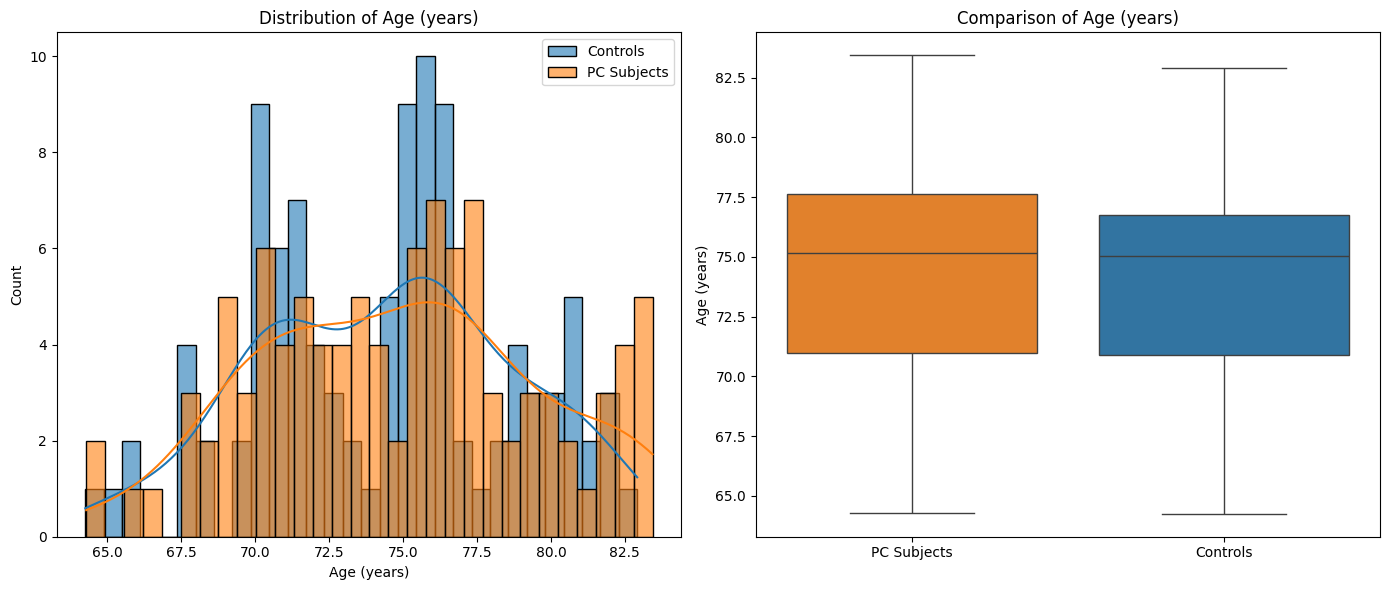

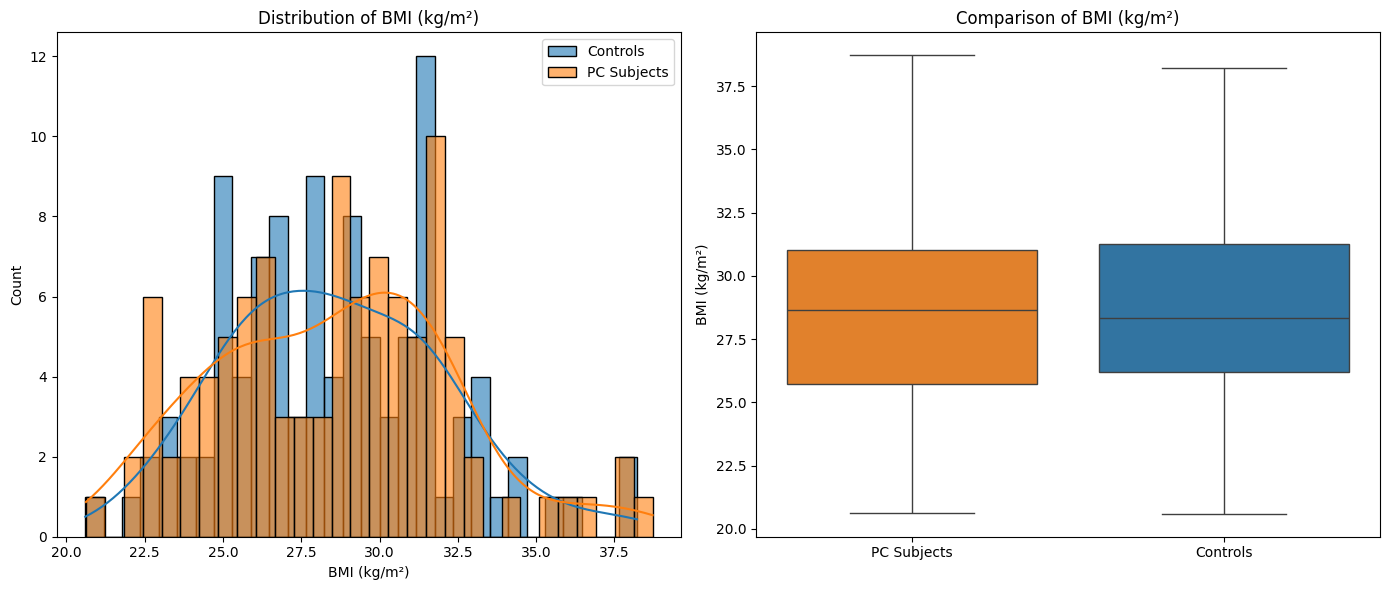

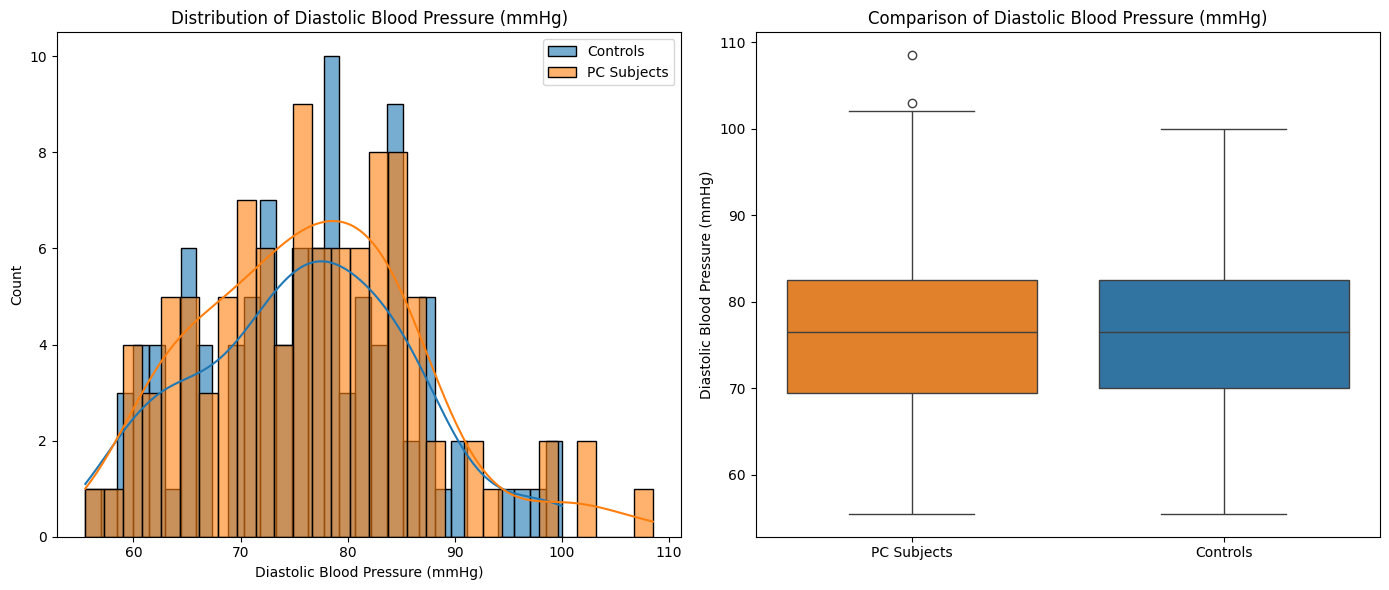

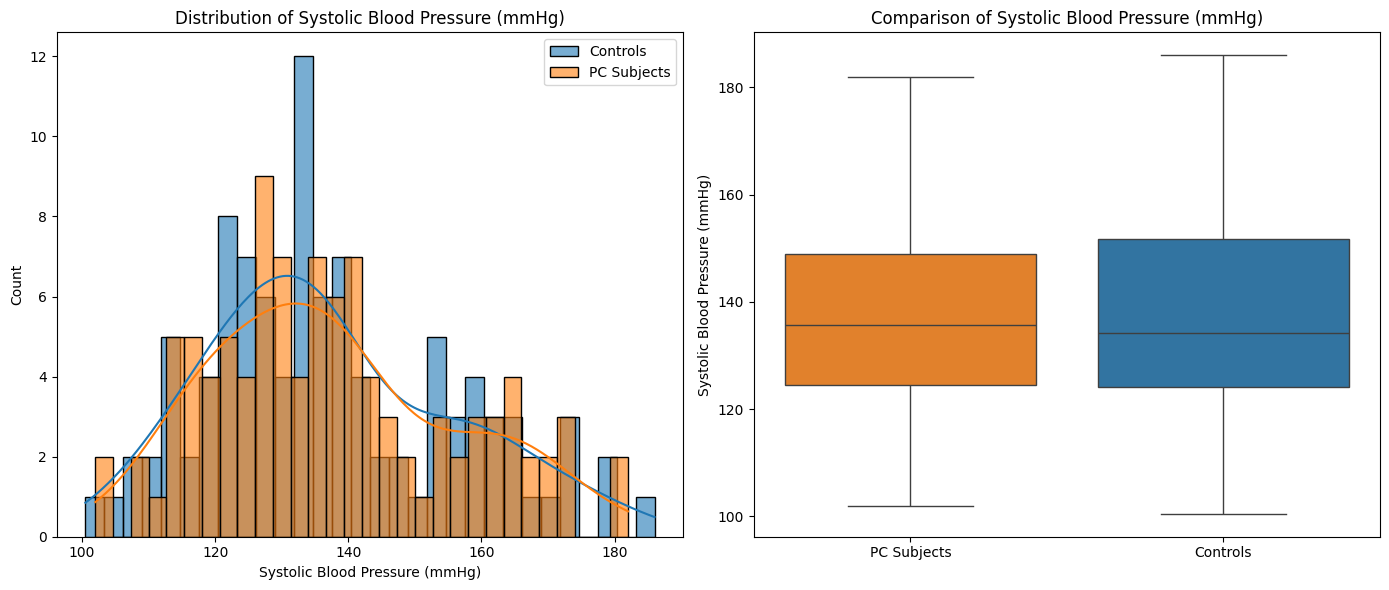


Visualizations saved as PDF files.


In [38]:
# Define features to visualize
visualization_features = {
    ('pc_age', 'control_age'): 'Age (years)',
    ('pc_bmi', 'control_bmi'): 'BMI (kg/m²)',
    ('pc_bp_diastolic', 'control_bp_diastolic'): 'Diastolic Blood Pressure (mmHg)',
    ('pc_bp_systolic', 'control_bp_systolic'): 'Systolic Blood Pressure (mmHg)'
}

# Create visualizations for each feature
for (pc_col, control_col), feature_name in visualization_features.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Histogram with KDE
    axes[0].set_title(f'Distribution of {feature_name}')
    sns.histplot(
        all_matches_sorted[control_col], 
        kde=True, bins=30, color='C0', 
        label='Controls', ax=axes[0], alpha=0.6
    )
    sns.histplot(
        all_matches_sorted[pc_col], 
        kde=True, bins=30, color='C1', 
        label='PC Subjects', ax=axes[0], alpha=0.6
    )
    axes[0].set_xlabel(feature_name)
    axes[0].legend()
    
    # Boxplot
    axes[1].set_title(f'Comparison of {feature_name}')
    boxplot_data = pd.DataFrame({
        'PC Subjects': all_matches_sorted[pc_col],
        'Controls': all_matches_sorted[control_col]
    })
    sns.boxplot(data=boxplot_data, palette=['C1', 'C0'], ax=axes[1])
    axes[1].set_ylabel(feature_name)
    
    # Save figure
    plt.tight_layout()
    filename = feature_name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '')
    plt.savefig(f'matching_quality_{filename}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

print("\nVisualizations saved as PDF files.")

## Summary Statistics

Display summary statistics of the matching results.

In [39]:
print("\n=== MATCHING SUMMARY ===")
print(f"\nTotal matched pairs: {len(all_matches_sorted)}")
print(f"\nBy PC type:")
print(all_matches_sorted['pc_type'].value_counts())
print(f"\nAverage matching distance (standardized units): {all_matches_sorted['matching_distance'].mean():.4f}")
print(f"\nMatches with blood pressure data: {all_matches_sorted['pc_bp_systolic'].notna().sum()}")
print(f"Matches without blood pressure data: {all_matches_sorted['pc_bp_systolic'].isna().sum()}")


=== MATCHING SUMMARY ===

Total matched pairs: 103

By PC type:
pc_type
V     52
SV    51
Name: count, dtype: int64

Average matching distance (standardized units): 0.4501

Matches with blood pressure data: 102
Matches without blood pressure data: 1
